# Ask-Your-Data — Layer 1 (SQL / database)
Khaula's part: schema design, loading the Olist dataset, and core exploratory queries.

Run each cell top to bottom with **Shift+Enter**. In VS Code, open this file and it opens
in the Jupyter notebook editor (the Jupyter extension must be installed).

## 1. Get the data

Two options — use whichever works for you:

**Option A — Kaggle API (needs `kaggle.json` set up, see setup guide)**
Run the cell below; it downloads and unzips automatically into `data/raw/`.

**Option B — Manual download**
Go to https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce, click Download,
unzip it, and put the 9 CSV files into a `data/raw/` folder next to this notebook.
Then skip the next cell and go straight to Section 2.

In [17]:
import os
print(os.path.exists("data/raw"), os.listdir("data/raw") if os.path.exists("data/raw") else "not found")

True ['olist_sellers_dataset.csv', 'product_category_name_translation.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv']


## 2. Build the SQLite database from the schema

In [18]:
import sqlite3
from pathlib import Path

DB_PATH = Path("olist.db")
SCHEMA_PATH = Path("sql/schema.sql")

if DB_PATH.exists():
    DB_PATH.unlink()  # start clean each run

conn = sqlite3.connect(DB_PATH)
conn.executescript(SCHEMA_PATH.read_text(encoding="utf-8"))
print("Schema created:", DB_PATH.resolve())

Schema created: /Users/khaula/Desktop/ask-your-data:/olist.db


## 3. Load each CSV into its table

In [19]:
import pandas as pd
from pathlib import Path

RAW_DIR = Path("data/raw")

TABLE_MAP = [
    ("olist_customers_dataset.csv", "customers", {}),
    ("olist_geolocation_dataset.csv", "geolocation", {}),
    ("olist_sellers_dataset.csv", "sellers", {}),
    ("product_category_name_translation.csv", "product_category_translation", {}),
    ("olist_products_dataset.csv", "products", {
        "product_name_lenght": "product_name_length",
        "product_description_lenght": "product_description_length",
    }),
    ("olist_orders_dataset.csv", "orders", {}),
    ("olist_order_items_dataset.csv", "order_items", {}),
    ("olist_order_payments_dataset.csv", "order_payments", {}),
    ("olist_order_reviews_dataset.csv", "order_reviews", {}),
]

# Known gap in the raw Kaggle file: these 2 category names appear in
# products.csv but are missing from product_category_name_translation.csv.
# Verified via orphan check — see notebook history.
MISSING_TRANSLATIONS = [
    ("pc_gamer", "pc_gamer"),
    ("portateis_cozinha_e_preparadores_de_alimentos", "portable_kitchen_food_preparators"),
]

for csv_name, table, renames in TABLE_MAP:
    csv_path = RAW_DIR / csv_name
    if not csv_path.exists():
        print(f"[skip] {csv_name} not found in data/raw/ — check your download")
        continue
    df = pd.read_csv(csv_path)
    if renames:
        df = df.rename(columns=renames)
    df.to_sql(table, conn, if_exists="append", index=False)
    print(f"[ok] {table:<28} {len(df):>7,} rows")

    if table == "product_category_translation":
        conn.executemany(
            "INSERT INTO product_category_translation "
            "(product_category_name, product_category_name_english) VALUES (?, ?)",
            MISSING_TRANSLATIONS,
        )
        conn.commit()
        print(f"[ok] patched {len(MISSING_TRANSLATIONS)} missing category translations")

conn.commit()

[ok] customers                     99,441 rows
[ok] geolocation                  1,000,163 rows
[ok] sellers                        3,095 rows
[ok] product_category_translation      71 rows
[ok] patched 2 missing category translations
[ok] products                      32,951 rows
[ok] orders                        99,441 rows
[ok] order_items                  112,650 rows
[ok] order_payments               103,886 rows
[ok] order_reviews                 99,224 rows


## 4. Sanity check — row counts per table

If any table shows 0 rows, that CSV didn't load — check the filename in `data/raw/`.

In [20]:
tables = ["customers", "geolocation", "sellers", "product_category_translation",
          "products", "orders", "order_items", "order_payments", "order_reviews"]

for t in tables:
    n = pd.read_sql(f"SELECT COUNT(*) AS n FROM {t}", conn).iloc[0, 0]
    print(f"{t:<28} {n:>8,} rows")

customers                      99,441 rows
geolocation                  1,000,163 rows
sellers                         3,095 rows
product_category_translation       73 rows
products                       32,951 rows
orders                         99,441 rows
order_items                   112,650 rows
order_payments                103,886 rows
order_reviews                  99,224 rows


In [21]:
# Orphan check — for each foreign-key relationship, count rows whose
# parent key doesn't exist in the parent table
checks = [
    ("orders.customer_id -> customers.customer_id",
     "SELECT COUNT(*) FROM orders WHERE customer_id NOT IN (SELECT customer_id FROM customers)"),
    ("order_items.order_id -> orders.order_id",
     "SELECT COUNT(*) FROM order_items WHERE order_id NOT IN (SELECT order_id FROM orders)"),
    ("order_items.product_id -> products.product_id",
     "SELECT COUNT(*) FROM order_items WHERE product_id NOT IN (SELECT product_id FROM products)"),
    ("order_items.seller_id -> sellers.seller_id",
     "SELECT COUNT(*) FROM order_items WHERE seller_id NOT IN (SELECT seller_id FROM sellers)"),
    ("order_payments.order_id -> orders.order_id",
     "SELECT COUNT(*) FROM order_payments WHERE order_id NOT IN (SELECT order_id FROM orders)"),
    ("order_reviews.order_id -> orders.order_id",
     "SELECT COUNT(*) FROM order_reviews WHERE order_id NOT IN (SELECT order_id FROM orders)"),
    ("products.product_category_name -> product_category_translation.product_category_name",
     "SELECT COUNT(*) FROM products WHERE product_category_name NOT IN (SELECT product_category_name FROM product_category_translation) AND product_category_name IS NOT NULL"),
]

for label, q in checks:
    n = pd.read_sql(q, conn).iloc[0, 0]
    status = "OK (0 orphans)" if n == 0 else f"⚠ {n} orphan rows"
    print(f"{label:<65} {status}")

orders.customer_id -> customers.customer_id                       OK (0 orphans)
order_items.order_id -> orders.order_id                           OK (0 orphans)
order_items.product_id -> products.product_id                     OK (0 orphans)
order_items.seller_id -> sellers.seller_id                        OK (0 orphans)
order_payments.order_id -> orders.order_id                        OK (0 orphans)
order_reviews.order_id -> orders.order_id                         OK (0 orphans)
products.product_category_name -> product_category_translation.product_category_name OK (0 orphans)


In [22]:
checks = [
    ("orders.customer_id -> customers.customer_id",
     "SELECT COUNT(*) FROM orders WHERE customer_id NOT IN (SELECT customer_id FROM customers)"),
    ("order_items.order_id -> orders.order_id",
     "SELECT COUNT(*) FROM order_items WHERE order_id NOT IN (SELECT order_id FROM orders)"),
    ("order_items.product_id -> products.product_id",
     "SELECT COUNT(*) FROM order_items WHERE product_id NOT IN (SELECT product_id FROM products)"),
    ("order_items.seller_id -> sellers.seller_id",
     "SELECT COUNT(*) FROM order_items WHERE seller_id NOT IN (SELECT seller_id FROM sellers)"),
    ("order_payments.order_id -> orders.order_id",
     "SELECT COUNT(*) FROM order_payments WHERE order_id NOT IN (SELECT order_id FROM orders)"),
    ("order_reviews.order_id -> orders.order_id",
     "SELECT COUNT(*) FROM order_reviews WHERE order_id NOT IN (SELECT order_id FROM orders)"),
    ("products.product_category_name -> product_category_translation.product_category_name",
     "SELECT COUNT(*) FROM products WHERE product_category_name NOT IN (SELECT product_category_name FROM product_category_translation) AND product_category_name IS NOT NULL"),
]

for label, q in checks:
    n = pd.read_sql(q, conn).iloc[0, 0]
    status = "OK (0 orphans)" if n == 0 else f"⚠ {n} orphan rows"
    print(f"{label:<65} {status}")

orders.customer_id -> customers.customer_id                       OK (0 orphans)
order_items.order_id -> orders.order_id                           OK (0 orphans)
order_items.product_id -> products.product_id                     OK (0 orphans)
order_items.seller_id -> sellers.seller_id                        OK (0 orphans)
order_payments.order_id -> orders.order_id                        OK (0 orphans)
order_reviews.order_id -> orders.order_id                         OK (0 orphans)
products.product_category_name -> product_category_translation.product_category_name OK (0 orphans)


In [23]:
q_orphans = """
SELECT DISTINCT product_category_name, COUNT(*) AS num_products
FROM products
WHERE product_category_name NOT IN (SELECT product_category_name FROM product_category_translation)
  AND product_category_name IS NOT NULL
GROUP BY product_category_name
"""
pd.read_sql(q_orphans, conn)

,product_category_name,num_products


## 5. Core queries

Each one runs and shows results as a pandas DataFrame.

In [24]:
# 5.1 Revenue by product category
q1 = '''
SELECT
    COALESCE(t.product_category_name_english, p.product_category_name, 'unknown') AS category,
    COUNT(DISTINCT oi.order_id)  AS num_orders,
    ROUND(SUM(oi.price), 2)      AS total_revenue,
    ROUND(AVG(oi.price), 2)      AS avg_item_price
FROM order_items oi
JOIN orders o                       ON o.order_id = oi.order_id
JOIN products p                     ON p.product_id = oi.product_id
LEFT JOIN product_category_translation t ON t.product_category_name = p.product_category_name
WHERE o.order_status = 'delivered'
GROUP BY category
ORDER BY total_revenue DESC
'''
pd.read_sql(q1, conn)

,category,num_orders,total_revenue,avg_item_price
0,health_beauty,8647,1233131.72,130.28
1,watches_gifts,5495,1166176.98,199.04
2,bed_bath_table,9272,1023434.76,93.44
3,sports_leisure,7530,954852.55,113.25
4,computers_accessories,6530,888724.61,116.26
...,...,...,...,...
69,flowers,29,1110.04,33.64
70,home_comfort_2,24,760.27,25.34
71,cds_dvds_musicals,12,730.00,52.14
72,fashion_childrens_clothes,7,519.95,74.28


In [25]:
# 5.2 Average delivery time (days) by customer state
q2 = '''
SELECT
    c.customer_state,
    COUNT(*) AS num_orders,
    ROUND(AVG(julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp)), 1) AS avg_delivery_days,
    ROUND(AVG(julianday(o.order_delivered_customer_date) - julianday(o.order_estimated_delivery_date)), 1) AS avg_days_late_vs_estimate
FROM orders o
JOIN customers c ON c.customer_id = o.customer_id
WHERE o.order_status = 'delivered' AND o.order_delivered_customer_date IS NOT NULL
GROUP BY c.customer_state
ORDER BY avg_delivery_days DESC
'''
pd.read_sql(q2, conn)

,customer_state,num_orders,avg_delivery_days,avg_days_late_vs_estimate
0,RR,41,29.4,-16.6
1,AP,67,27.2,-19.1
2,AM,145,26.4,-18.9
3,AL,397,24.5,-8.0
4,PA,946,23.8,-13.4
5,MA,717,21.6,-8.9
6,SE,335,21.5,-9.3
7,CE,1279,21.3,-10.1
8,AC,80,21.0,-20.1
9,PB,517,20.4,-12.6


In [26]:
# 5.3 Monthly revenue trend
q3 = '''
SELECT
    strftime('%Y-%m', o.order_purchase_timestamp) AS year_month,
    COUNT(DISTINCT o.order_id) AS num_orders,
    ROUND(SUM(oi.price + oi.freight_value), 2) AS total_revenue
FROM orders o
JOIN order_items oi ON oi.order_id = o.order_id
WHERE o.order_status = 'delivered'
GROUP BY year_month
ORDER BY year_month
'''
df3 = pd.read_sql(q3, conn)
df3

,year_month,num_orders,total_revenue
0,2016-09,1,143.46
1,2016-10,265,46490.66
2,2016-12,1,19.62
3,2017-01,750,127482.37
4,2017-02,1653,271239.32
5,2017-03,2546,414330.95
6,2017-04,2303,390812.40
7,2017-05,3546,566851.40
8,2017-06,3135,490050.37
9,2017-07,3872,566299.08


<Axes: title={'center': 'Monthly revenue'}, xlabel='year_month'>

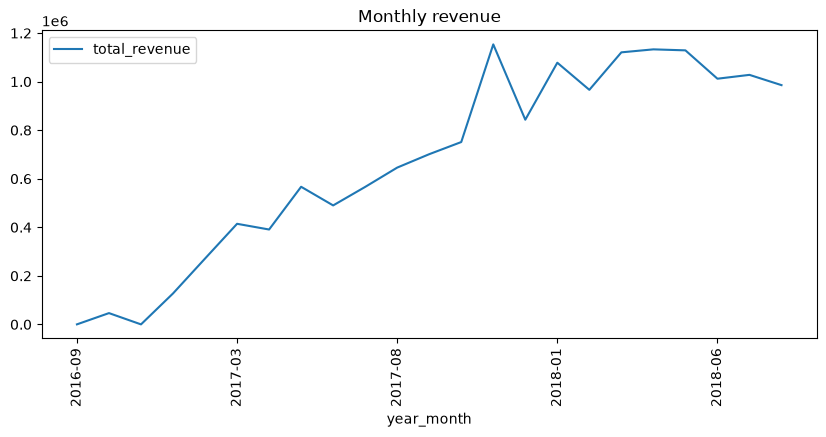

In [27]:
# Optional: plot the monthly revenue trend
df3.plot(x="year_month", y="total_revenue", kind="line", rot=90, figsize=(10,4), title="Monthly revenue")

In [28]:
# 5.4 Payment method breakdown
q4 = '''
SELECT
    payment_type,
    COUNT(*) AS num_payments,
    ROUND(SUM(payment_value), 2) AS total_value,
    ROUND(AVG(payment_installments), 1) AS avg_installments
FROM order_payments
GROUP BY payment_type
ORDER BY total_value DESC
'''
pd.read_sql(q4, conn)

,payment_type,num_payments,total_value,avg_installments
0,credit_card,76795,12542084.19,3.5
1,boleto,19784,2869361.27,1.0
2,voucher,5775,379436.87,1.0
3,debit_card,1529,217989.79,1.0
4,not_defined,3,0.00,1.0


In [29]:
# 5.5 Top 10 sellers by revenue
q5 = '''
SELECT
    s.seller_id,
    s.seller_state,
    COUNT(DISTINCT oi.order_id) AS num_orders,
    ROUND(SUM(oi.price), 2) AS total_revenue
FROM order_items oi
JOIN sellers s ON s.seller_id = oi.seller_id
JOIN orders o  ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
GROUP BY s.seller_id, s.seller_state
ORDER BY total_revenue DESC
LIMIT 10
'''
pd.read_sql(q5, conn)

,seller_id,seller_state,num_orders,total_revenue
0,4869f7a5dfa277a7dca6462dcf3b52b2,SP,1124,226987.93
1,53243585a1d6dc2643021fd1853d8905,BA,348,217940.44
2,4a3ca9315b744ce9f8e9374361493884,SP,1772,196882.12
3,fa1c13f2614d7b5c4749cbc52fecda94,SP,578,190917.14
4,7c67e1448b00f6e969d365cea6b010ab,SP,973,186570.05
5,7e93a43ef30c4f03f38b393420bc753a,SP,319,165981.49
6,da8622b14eb17ae2831f4ac5b9dab84a,SP,1311,159816.87
7,7a67c85e85bb2ce8582c35f2203ad736,SP,1145,139658.69
8,1025f0e2d44d7041d6cf58b6550e0bfa,SP,910,138208.56
9,955fee9216a65b617aa5c0531780ce60,SP,1261,131836.71


In [30]:
# 5.6 Review score vs delivery lateness, by category
# Fixed: an order with multiple items previously duplicated its review
# once per item. This version first collapses to one row per
# (order, category) pair, so a review counts once per category it touches.
q6 = '''
WITH order_categories AS (
    SELECT DISTINCT
        oi.order_id,
        p.product_category_name
    FROM order_items oi
    JOIN products p ON p.product_id = oi.product_id
)
SELECT
    COALESCE(t.product_category_name_english, oc.product_category_name, 'unknown') AS category,
    ROUND(AVG(r.review_score), 2) AS avg_review_score,
    COUNT(DISTINCT r.review_id) AS num_reviews,
    ROUND(AVG(
        julianday(o.order_delivered_customer_date) - julianday(o.order_estimated_delivery_date)
    ), 1) AS avg_days_late_vs_estimate
FROM order_reviews r
JOIN orders o ON o.order_id = r.order_id
JOIN order_categories oc ON oc.order_id = o.order_id
LEFT JOIN product_category_translation t ON t.product_category_name = oc.product_category_name
WHERE o.order_status = 'delivered' AND o.order_delivered_customer_date IS NOT NULL
GROUP BY category
HAVING num_reviews >= 30
ORDER BY avg_review_score ASC
LIMIT 15
'''
pd.read_sql(q6, conn)

,category,avg_review_score,num_reviews,avg_days_late_vs_estimate
0,office_furniture,3.64,1246,-11.2
1,fashion_male_clothing,3.82,105,-12.9
2,audio,3.83,346,-9.4
3,home_confort,3.88,393,-9.1
4,furniture_mattress_and_upholstery,3.89,37,-6.5
5,fashio_female_clothing,3.95,37,-11.3
6,construction_tools_safety,3.97,158,-12.1
7,fixed_telephony,3.97,210,-14.2
8,home_construction,3.99,482,-10.7
9,bed_bath_table,4.00,9191,-10.7


In [31]:
# 5.7 Order status funnel (data quality check)
q7 = '''
SELECT
    order_status,
    COUNT(*) AS num_orders,
    ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM orders), 1) AS pct_of_total
FROM orders
GROUP BY order_status
ORDER BY num_orders DESC
'''
pd.read_sql(q7, conn)

,order_status,num_orders,pct_of_total
0,delivered,96478,97.0
1,shipped,1107,1.1
2,canceled,625,0.6
3,unavailable,609,0.6
4,invoiced,314,0.3
5,processing,301,0.3
6,created,5,0.0
7,approved,2,0.0


## 6. Close the connection when done

(Re-run Section 2 onward if you need to rebuild the database from scratch.)

In [32]:
conn.close()